In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_excel(r"C:\Users\HP\Downloads\Churn_Modelling (3).xlsx")

In [3]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

In [5]:
df.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [7]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### outliers

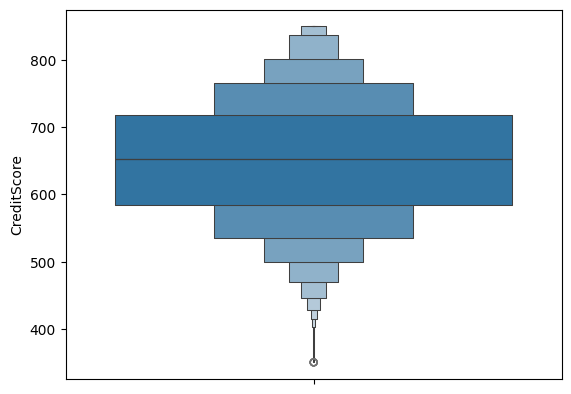

In [12]:
sns.boxenplot(df["CreditScore"])
plt.show()

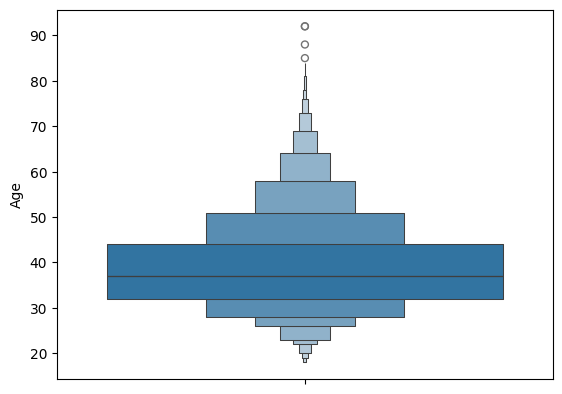

In [13]:
sns.boxenplot(df["Age"])
plt.show()

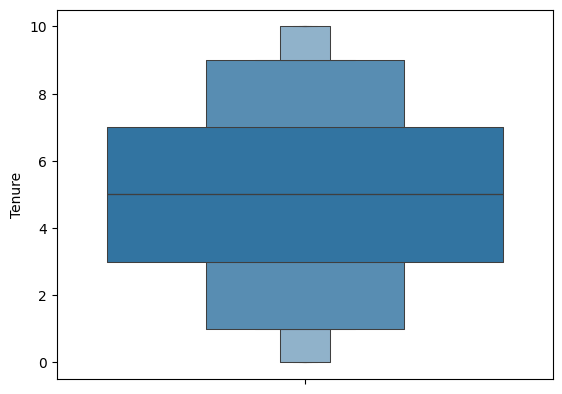

In [14]:
sns.boxenplot(df["Tenure"])
plt.show()

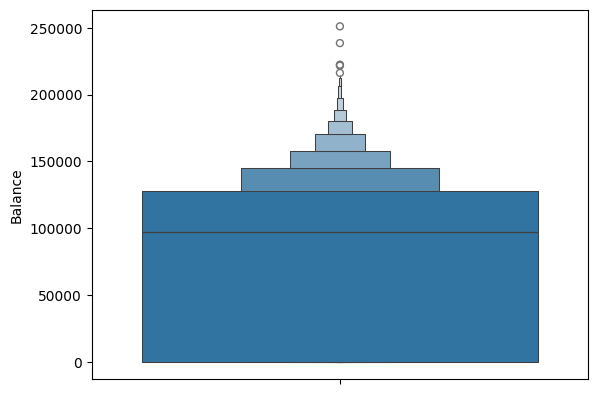

In [15]:
sns.boxenplot(df["Balance"])
plt.show()

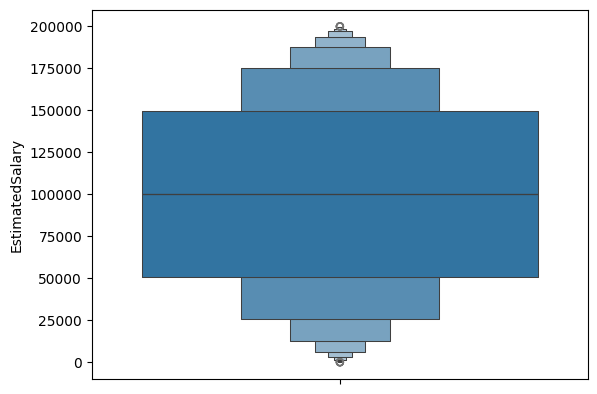

In [16]:
sns.boxenplot(df["EstimatedSalary"])
plt.show()

In [28]:
def outliers_iqr(pd_data, colu_to_ignore=[]):
    data=pd_data.copy()
    for i in data.columns:
        if i in colu_to_ignore:
            continue
        if pd.api.types.is_numeric_dtype(data[i]):
            q1=data[i].quantile(.25)
            q3=data[i].quantile(.75)
            iqr=q3-q1
            upper_limit=q3+1.5*iqr
            lower_limit=q1-1.5*iqr
            data[i]=data[i].clip(lower_limit, upper_limit)
    return data
df1=outliers_iqr(pd_data=df, colu_to_ignore=["HasCrCard","IsActiveMember","Exited" ])

In [29]:
# sns.boxenplot(y=df1["Balance"])
# plt.show()

## Encoding of categorical columns 

In [30]:
df2=pd.get_dummies(df1, drop_first=True, dtype="int")

In [40]:
# df2.columns

## Model development 

In [32]:
y=df2["Exited"]
x=df2.drop(columns=["Exited"])

In [33]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=.3, random_state=1988)

In [38]:
log_model=LogisticRegression(max_iter=10000)

In [43]:
log_model.fit(x_train, y_train)

In [41]:
log_model.score(x_train, y_train)

0.815

In [42]:
log_model.score(x_test, y_test)

0.8263333333333334